In [1]:
import accelforge as af
from accelforge.frontend import Spec
from accelforge.mapper import Metrics

spec = Spec.from_yaml(
    af.examples.arches.simple_heterogeneous,
    af.examples.workloads.bert,
)
spec.mapper.metrics = Metrics.ENERGY | Metrics.LATENCY
spec.mapper.n_concurrent_threads = 2
mappings = spec.map_workload_to_arch(einsum_names=["Q", "K", "QK"])

Getting energy, latency, and leak power for components running QK: 100%|██████████| 3/3 [00:00<00:00, 52.57it/s]
Generating pmapping templates for compute MacA Einsum K: 46it [00:00, 502.13it/s]
Generating pmapping templates for compute MacA Einsum Q: 46it [00:00, 559.42it/s]
Generating pmapping templates for compute MacB Einsum K: 46it [00:00, 503.59it/s]
Generating pmapping templates for compute MacB Einsum Q: 46it [00:00, 558.92it/s]
Generating pmapping templates for compute MacA Einsum QK: 79it [00:00, 524.05it/s]
Generating pmapping templates for compute MacB Einsum QK: 79it [00:00, 472.06it/s]
Generating jobs: 100%|██████████| 3/3 [00:01<00:00,  2.06it/s]


Einsum Q has 92 pmapping jobs:
	0	[WQ in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [Q in GlobalBuffer] T-b  T-d  T-e  T-h  T-m  MacA computes Q
	1	[WQ in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [Q in GlobalBuffer] T-d  T-e  T-h  [WQ in GlobalBuffer] T-b  T-m  MacA computes Q
	2	[WQ in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [Q in GlobalBuffer] T-b  T-d  T-e  T-h  T-m  MacB computes Q
	3	[WQ in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [Q in GlobalBuffer] T-d  T-e  T-h  [WQ in GlobalBuffer] T-b  T-m  MacB computes Q
	4	[WQ in MainMemory] T-b  T-m  [Q in GlobalBuffer] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-e  T-h  T-m  MacA computes Q
	5	[WQ in MainMemory] T-b  T-m  [Q in GlobalBuffer] T-b  T-d  T-m  [I in GlobalBuffer] T-d  T-e  T-h  [WQ in GlobalBuffer] T-b  T-m  MacA computes Q
	6	[WQ in MainMemory] T-b  T-m  [Q in GlobalBuffer] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-e  T-h  T-m  MacB c

Grouping pmappings for QK: 100%|██████████| 270/270 [00:01<00:00, 219.26it/s]


Q: 1.53e05 total, 3.88e04 (1/4) valid, 3.88e04 (1/4) evaluated, 1.12e04 (1/14) Pareto-Optimal
K: 1.53e05 total, 3.88e04 (1/4) valid, 3.88e04 (1/4) evaluated, 1.12e04 (1/14) Pareto-Optimal
QK: 7.24e05 total, 1.35e05 (1/5) valid, 1.40e05 (1/5) evaluated, 6.20e04 (1/12) Pareto-Optimal
Total: 1.03e06 total, 2.13e05 (1/5) valid, 2.17e05 (1/5) evaluated, 8.44e04 (1/12) Pareto-Optimal


Compressing pmappings: 100%|██████████| 3/3 [00:01<00:00,  2.67it/s]


...

Dirty pruning pmappings: 100%|██████████| 368/368 [00:00<00:00, 1616.62it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 58756 -> 58756 (100.00% kept) pmappings
Not tracking MacA because it is never reserved for multiple pmappings.
Not tracking MacB because it is never reserved for multiple pmappings.


Grouping pmappings: 100%|██████████| 1/1 [00:00<00:00, 12.65it/s]


Dirty joining mapping(s) valid & optimal! Returning...


Evaluating chosen mappings in detail: 100%|██████████| 3/3 [00:00<00:00,  3.65it/s]


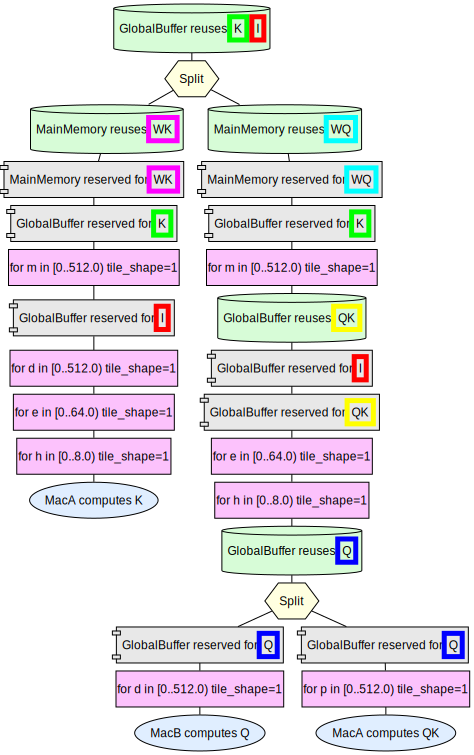

In [3]:
mappings[0].render()

In [4]:
mappings.data[[c for c in mappings.data if "latency" in c]]

,Total<SEP>latency,K<SEP>latency<SEP>MacA,K<SEP>latency<SEP>GlobalBuffer,K<SEP>latency<SEP>MainMemory,Q<SEP>latency<SEP>MacB,Q<SEP>latency<SEP>GlobalBuffer,Q<SEP>latency<SEP>MainMemory,QK<SEP>latency<SEP>MacA,QK<SEP>latency<SEP>GlobalBuffer
0,268435456.0,134217728.0,0.0,0.0,134217728.0,0.0,0.0,134217728.0,0.0
0,268435456.0,134217728.0,0.0,0.0,134217728.0,0.0,0.0,134217728.0,0.0
0,268435456.0,134217728.0,0.0,0.0,134217728.0,0.0,0.0,134217728.0,0.0
